In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Optional for interactive charts
import plotly.express as px

plt.style.use('ggplot')

In [10]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [13]:
print("Shape:", df.shape)


Shape: (1000, 9)


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [15]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [16]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [17]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

In [20]:
df['Date'] = pd.to_datetime(df['Date'])

In [22]:
df['Month'] = df['Date'].dt.month_name()

df['Year'] = df['Date'].dt.year

df['Quarter'] = df['Date'].dt.quarter

df['Day'] = df['Date'].dt.day_name()

In [23]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,18,30,45,60,100],
    labels=['Teen','Young Adult','Adult','Middle Age','Senior']
)

In [24]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Quarter,Day,Age_Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,4,Friday,Adult
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,1,Monday,Young Adult
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,2023,1,Friday,Middle Age
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,2,Sunday,Adult
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,2,Saturday,Young Adult


In [25]:
total_revenue = df['Total Amount'].sum()

avg_order_value = df['Total Amount'].mean()

total_customers = df['Customer ID'].nunique()

total_transactions = len(df)

print("Total Revenue:", total_revenue)
print("Average Order Value:", round(avg_order_value,2))
print("Total Customers:", total_customers)
print("Total Transactions:", total_transactions)

Total Revenue: 456000
Average Order Value: 456.0
Total Customers: 1000
Total Transactions: 1000


In [26]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Year,Quarter
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000,2023.002000,2.525000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,2023.000000,1.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2023.000000,2.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2023.000000,2.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,2023.000000,4.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2024.000000,4.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.044699,1.119208


In [27]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

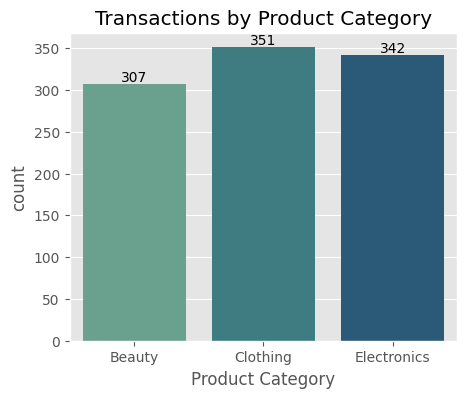

In [59]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df,
    x='Product Category',
    hue='Product Category',
    palette='crest',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Transactions by Product Category")
plt.show()

In [29]:
category_sales = df.groupby(
    'Product Category'
)['Total Amount'].sum().sort_values(ascending=False)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

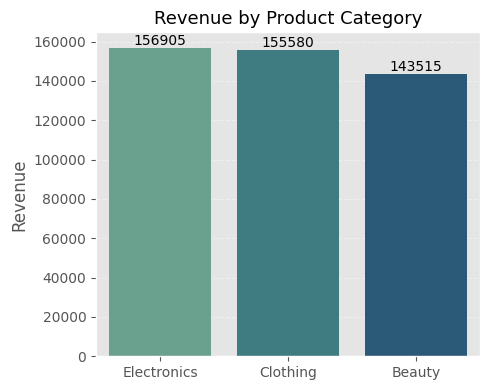

In [61]:
plt.figure(figsize=(5,4))

ax = sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette='crest',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Revenue by Product Category", fontsize=13)
plt.xlabel("")
plt.ylabel("Revenue")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [31]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

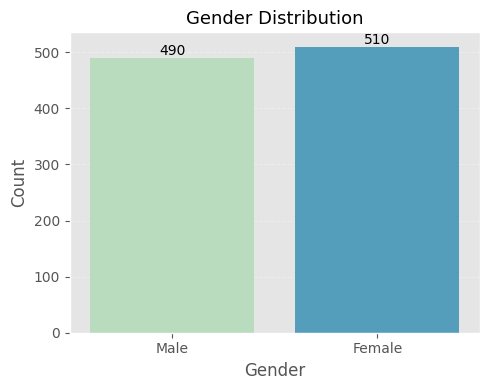

In [60]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df,
    x='Gender',
    hue='Gender',
    palette='GnBu',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution", fontsize=13)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

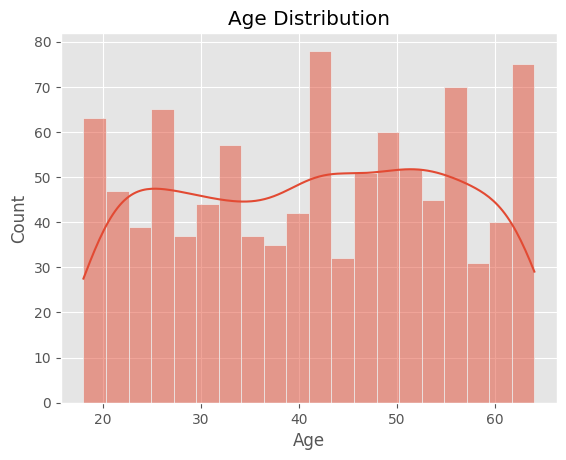

In [33]:
sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

In [34]:
age_group_sales = df.groupby(
    'Age_Group'
)['Total Amount'].sum()

age_group_sales

Age_Group
Teen            11215
Young Adult    121730
Adult          141955
Middle Age     147875
Senior          33225
Name: Total Amount, dtype: int64

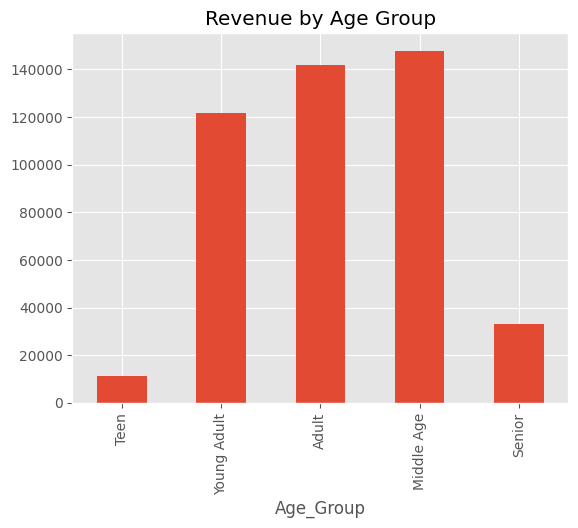

In [35]:
age_group_sales.plot(
    kind='bar'
)

plt.title("Revenue by Age Group")
plt.show()

In [36]:
monthly_sales = df.groupby(
    'Month'
)['Total Amount'].sum()

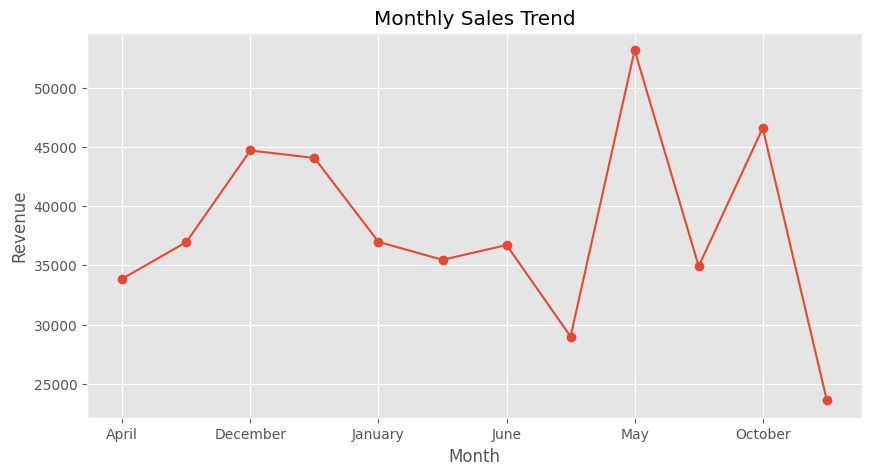

In [37]:
monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

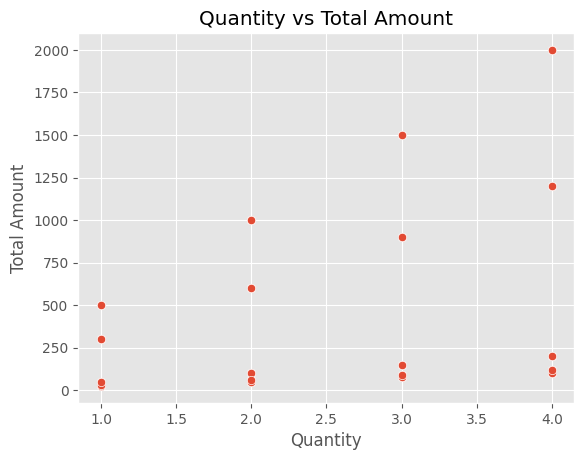

In [38]:
sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total Amount'
)

plt.title("Quantity vs Total Amount")
plt.show()

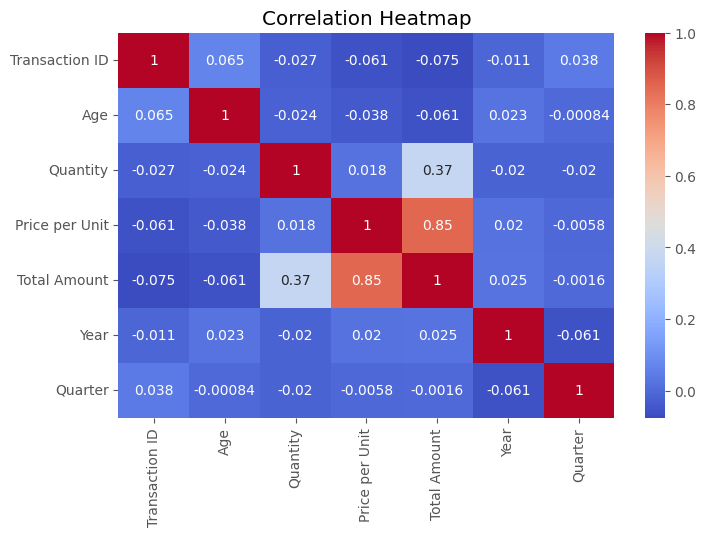

In [39]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [40]:
top_transactions = df.sort_values(
    by='Total Amount',
    ascending=False
).head(10)

top_transactions

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Quarter,Day,Age_Group
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000,May,2023,2,Monday,Senior
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000,May,2023,2,Tuesday,Young Adult
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000,January,2023,1,Monday,Adult
576,577,2023-02-13,CUST577,Male,21,Beauty,4,500,2000,February,2023,1,Monday,Young Adult
571,572,2023-04-20,CUST572,Male,31,Clothing,4,500,2000,April,2023,2,Thursday,Adult
268,269,2023-02-01,CUST269,Male,25,Clothing,4,500,2000,February,2023,1,Wednesday,Young Adult
502,503,2023-10-25,CUST503,Male,45,Beauty,4,500,2000,October,2023,4,Wednesday,Adult
926,927,2023-06-24,CUST927,Male,43,Electronics,4,500,2000,June,2023,2,Saturday,Adult
252,253,2023-08-31,CUST253,Female,53,Clothing,4,500,2000,August,2023,3,Thursday,Middle Age
546,547,2023-03-07,CUST547,Male,63,Clothing,4,500,2000,March,2023,1,Tuesday,Senior


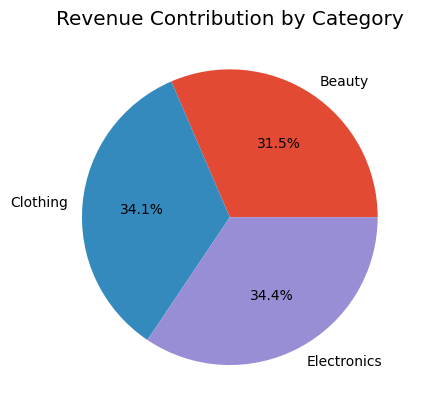

In [73]:
category_revenue = df.groupby(
    'Product Category'
)['Total Amount'].sum()

category_revenue.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution by Category")
plt.ylabel("")
plt.show()

In [45]:
monthly_sales = df.groupby(
    df['Date'].dt.month
)['Total Amount'].sum()

growth_rate = monthly_sales.pct_change()*100

growth_rate

Date
1           NaN
2     19.145484
3    -34.203359
4     16.833391
5     56.923531
6    -30.921919
7     -3.404603
8      4.215424
9    -36.093074
10    97.205758
11   -25.032203
12    27.978236
Name: Total Amount, dtype: float64

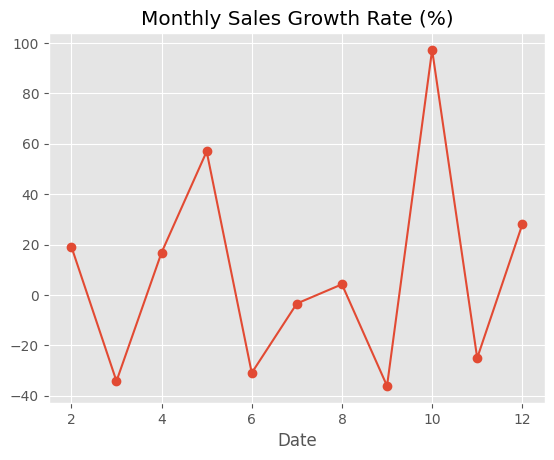

In [46]:
growth_rate.plot(
    marker='o'
)

plt.title("Monthly Sales Growth Rate (%)")
plt.show()

In [75]:
quantity_sales = df.groupby(
    'Product Category'
)['Quantity'].sum()

print(quantity_sales)

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64


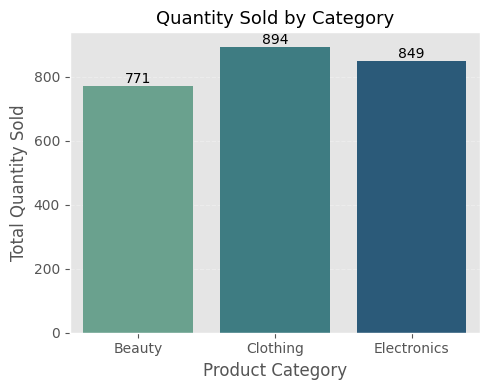

In [76]:
plt.figure(figsize=(5,4))

ax = sns.barplot(
    x=quantity_sales.index,
    y=quantity_sales.values,
    hue=quantity_sales.index,
    palette='crest',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Quantity Sold by Category", fontsize=13)
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

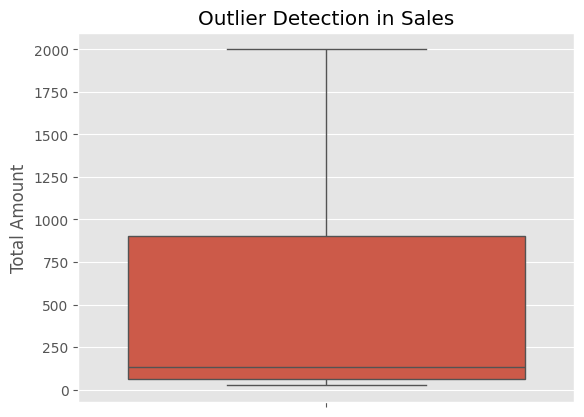

In [48]:
sns.boxplot(
    y=df['Total Amount']
)

plt.title("Outlier Detection in Sales")
plt.show()

In [50]:
customer_summary = df.groupby(
    'Customer ID'
).agg({
    'Total Amount':'sum',
    'Transaction ID':'count'
})

customer_summary.columns = [
    'Total_Spent',
    'Transactions'
]

customer_summary.head()

,Total_Spent,Transactions
Customer ID,,
CUST001,150,1
CUST002,1000,1
CUST003,30,1
CUST004,500,1
CUST005,100,1


In [51]:
customer_summary.sort_values(
    by='Total_Spent',
    ascending=False
).head(10)

,Total_Spent,Transactions
Customer ID,,
CUST015,2000,1
CUST412,2000,1
CUST970,2000,1
CUST547,2000,1
CUST281,2000,1
CUST416,2000,1
CUST420,2000,1
CUST927,2000,1
CUST447,2000,1


In [67]:
df['Spending_Level'] = pd.cut(
    df['Total Amount'],
    bins=[0, 200, 800, 2000],
    labels=['Low', 'Medium', 'High']
)

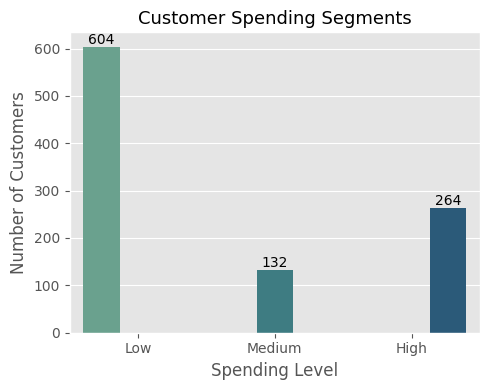

In [68]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df,
    x='Spending_Level',
    hue='Spending_Level',
    palette='crest',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Spending Segments", fontsize=13)
plt.xlabel("Spending Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [70]:
top_customers = df.groupby(
    'Customer ID'
)['Total Amount'].sum().sort_values(
    ascending=False
).head(10)

top_customers

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

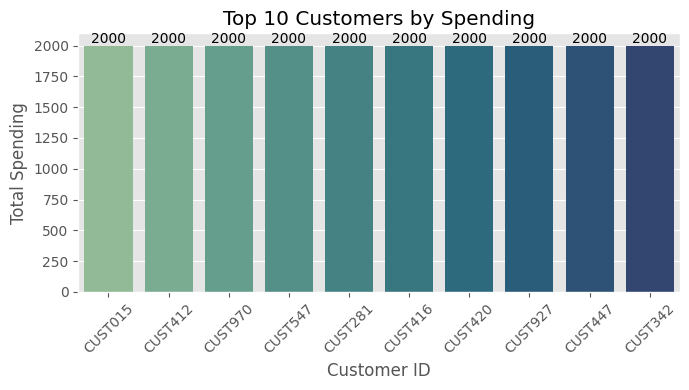

In [71]:
plt.figure(figsize=(7,4))

ax = sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers.values,
    hue=top_customers.index.astype(str),
    palette='crest',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [74]:
print("""
RETAIL SALES ANALYSIS INSIGHTS

1. Electronics generated the highest revenue,
making it the most profitable product category.

2. Clothing recorded the highest number of
transactions, indicating strong customer demand.

3. Customer distribution is nearly balanced
between male and female customers.

4. Most customers belong to the young adult
and middle-age groups, contributing significantly
to overall sales.

5. Sales performance varies across months,
indicating seasonal purchasing patterns.

6. High-value customers contribute a substantial
portion of total revenue and should be targeted
through loyalty programs.

7. There is a positive relationship between
quantity purchased and transaction value,
showing that bulk purchases increase revenue.

8. Product categories contribute relatively
balanced revenue, reducing dependence on a
single category.

9. Customer spending segmentation reveals
opportunities for targeted marketing strategies.

10. Data-driven insights can help optimize
inventory management, customer retention,
and overall business profitability.
""")


RETAIL SALES ANALYSIS INSIGHTS

1. Electronics generated the highest revenue,
making it the most profitable product category.

2. Clothing recorded the highest number of
transactions, indicating strong customer demand.

3. Customer distribution is nearly balanced
between male and female customers.

4. Most customers belong to the young adult
and middle-age groups, contributing significantly
to overall sales.

5. Sales performance varies across months,
indicating seasonal purchasing patterns.

6. High-value customers contribute a substantial
portion of total revenue and should be targeted
through loyalty programs.

7. There is a positive relationship between
quantity purchased and transaction value,
showing that bulk purchases increase revenue.

8. Product categories contribute relatively
balanced revenue, reducing dependence on a
single category.

9. Customer spending segmentation reveals
opportunities for targeted marketing strategies.

10. Data-driven insights can help optimize
inve